**Sector 1: Testing code for presentation/report**

In [1]:
!pip install geopandas contextily shapely matplotlib seaborn


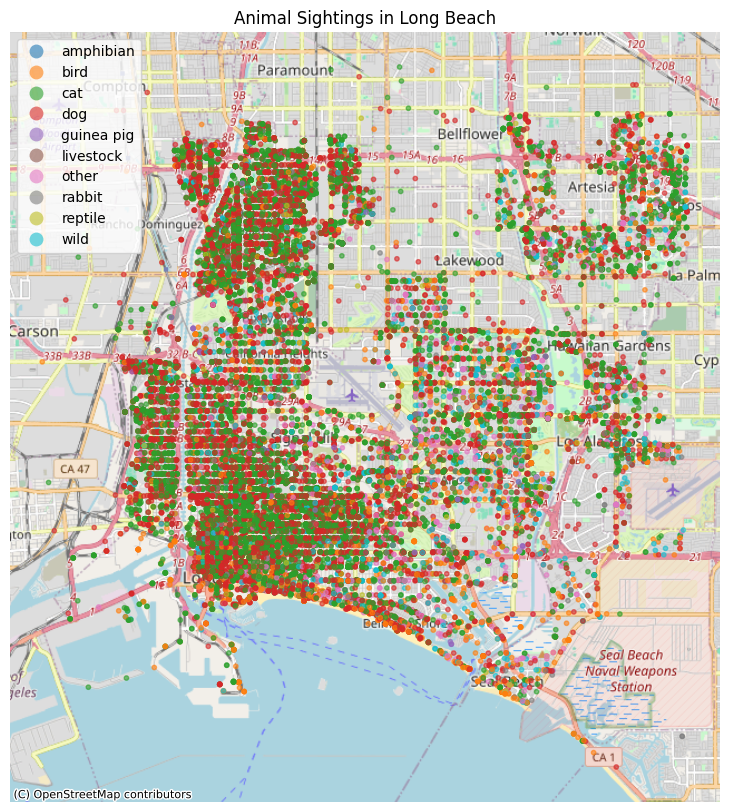

In [2]:
# Install required packages if not already installed
# Uncomment these lines if you're running in Google Colab
# !pip install geopandas contextily shapely matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

# Load the dataset
df = pd.read_csv('data/longbeach.csv')

# Select relevant columns and drop rows with missing lat/lon
df = df[['animal_type', 'latitude', 'longitude']].dropna()

# Convert lat/lon to numeric, coercing errors to NaN, then drop NaNs
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df = df.dropna(subset=['latitude', 'longitude'])

# Filter for Long Beach area (approximate bounds)
long_beach_bounds = {
    'lat_min': 33.7, 'lat_max': 33.9,
    'lon_min': -118.25, 'lon_max': -118.05
}

df_filtered = df[
    (df['latitude'] >= long_beach_bounds['lat_min']) &
    (df['latitude'] <= long_beach_bounds['lat_max']) &
    (df['longitude'] >= long_beach_bounds['lon_min']) &
    (df['longitude'] <= long_beach_bounds['lon_max'])
]

# Create a GeoDataFrame
geometry = [Point(xy) for xy in zip(df_filtered['longitude'], df_filtered['latitude'])]
gdf = gpd.GeoDataFrame(df_filtered, geometry=geometry, crs="EPSG:4326")

# Convert to Web Mercator (required by contextily)
gdf = gdf.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, column='animal_type', legend=True, markersize=10, alpha=0.6)

# Add a base map (e.g., OpenStreetMap)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Remove axis
ax.set_axis_off()
plt.title("Animal Sightings in Long Beach")
plt.show()



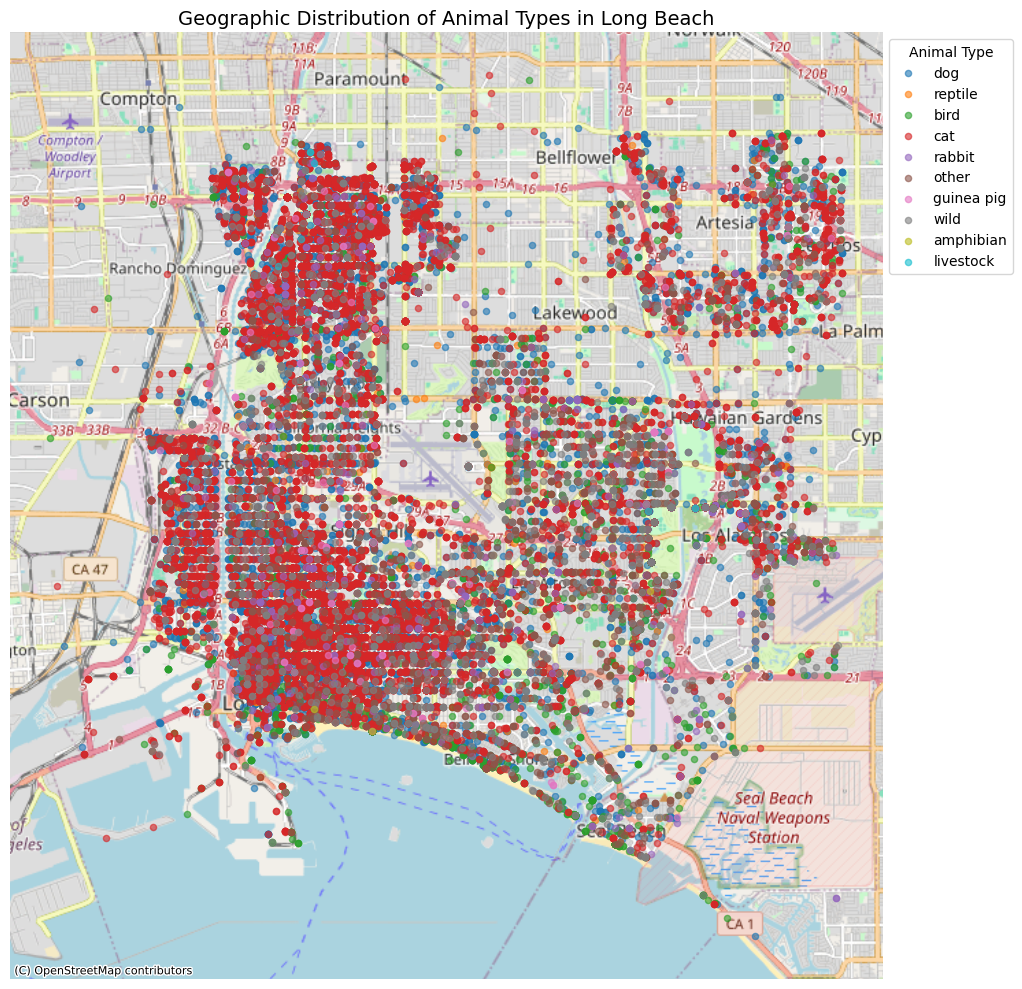

In [3]:
# Install required packages (if needed)
# !pip install geopandas contextily shapely matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

# Load and clean data
df = pd.read_csv('data/longbeach.csv')
df = df[['animal_type', 'latitude', 'longitude']].dropna()
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df = df.dropna(subset=['latitude', 'longitude'])

# Filter for Long Beach area
long_beach_bounds = {
    'lat_min': 33.7, 'lat_max': 33.9,
    'lon_min': -118.25, 'lon_max': -118.05
}
df_filtered = df[
    (df['latitude'] >= long_beach_bounds['lat_min']) &
    (df['latitude'] <= long_beach_bounds['lat_max']) &
    (df['longitude'] >= long_beach_bounds['lon_min']) &
    (df['longitude'] <= long_beach_bounds['lon_max'])
]

# Create GeoDataFrame and project to Web Mercator
geometry = [Point(xy) for xy in zip(df_filtered['longitude'], df_filtered['latitude'])]
gdf = gpd.GeoDataFrame(df_filtered, geometry=geometry, crs="EPSG:4326")
gdf_web_mercator = gdf.to_crs(epsg=3857)

# Get unique animal types and assign colors
animal_types = df_filtered['animal_type'].unique()
colors = plt.cm.tab10(range(len(animal_types)))
color_dict = {animal: color for animal, color in zip(animal_types, colors)}

# Create the plot
fig, ax = plt.subplots(figsize=(10, 10))
for animal in animal_types:
    subset = gdf_web_mercator[gdf_web_mercator['animal_type'] == animal]
    subset.plot(ax=ax, color=color_dict[animal], markersize=20, alpha=0.6, label=animal)

# Add basemap and customize plot
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title('Geographic Distribution of Animal Types in Long Beach', fontsize=14)
ax.legend(title="Animal Type", loc='upper left', bbox_to_anchor=(1, 1))
ax.set_axis_off()

plt.tight_layout()
plt.show()


In [4]:
!pip install geopandas contextily shapely matplotlib seaborn


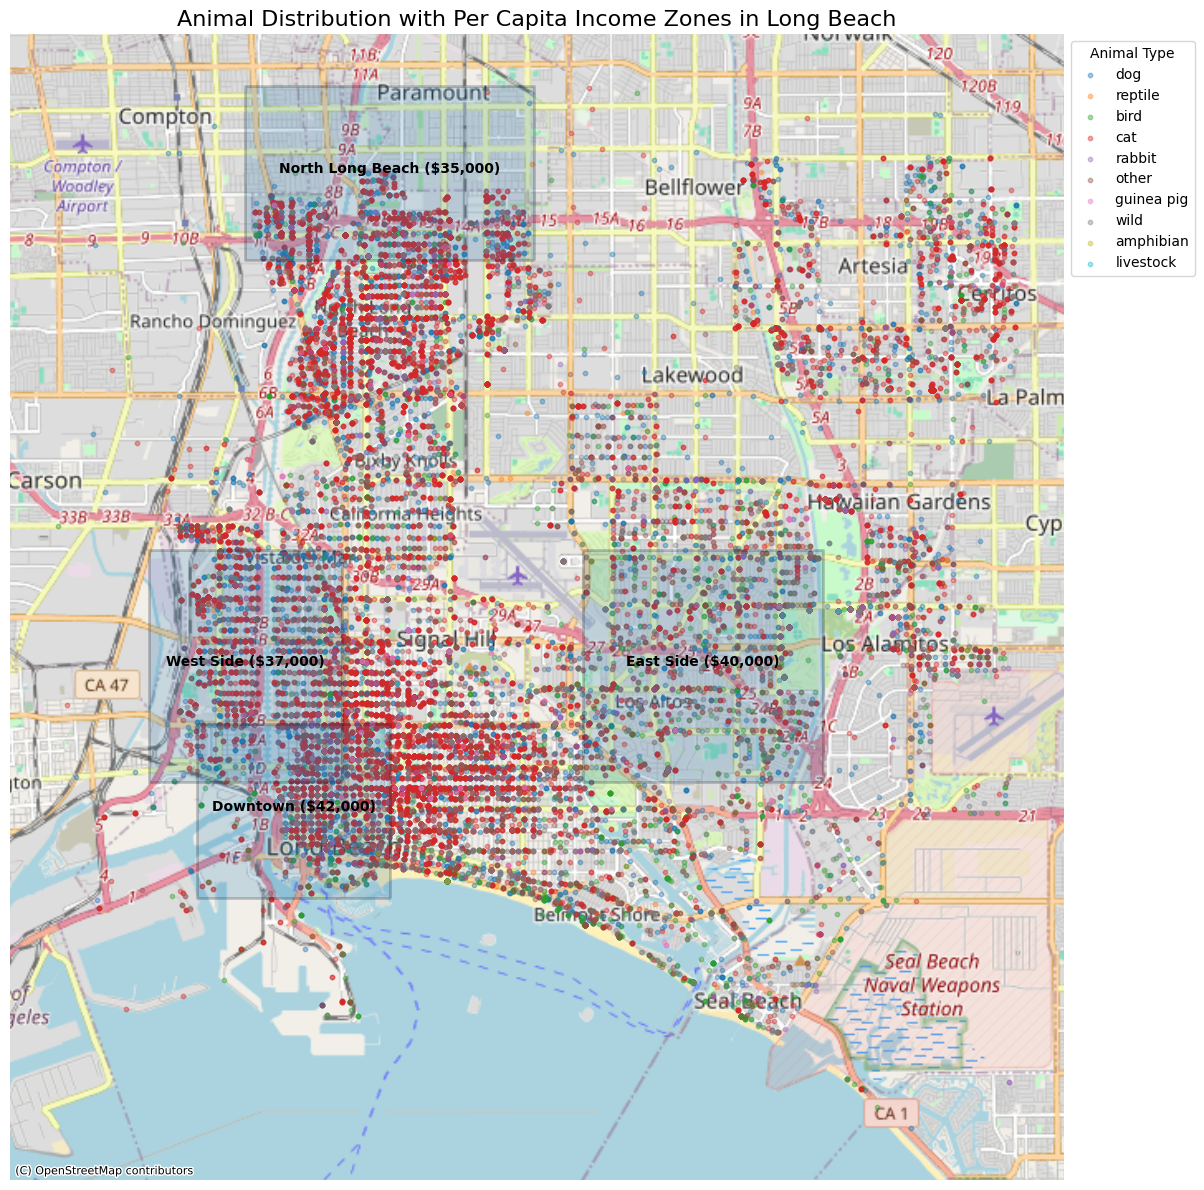

In [5]:
# Install required packages if needed
# !pip install geopandas contextily shapely matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point, box

# Load and clean animal data
df = pd.read_csv('data/longbeach.csv')
df = df[['animal_type', 'latitude', 'longitude']].dropna()
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df = df.dropna(subset=['latitude', 'longitude'])

# Filter to Long Beach area
long_beach_bounds = {
    'lat_min': 33.7, 'lat_max': 33.9,
    'lon_min': -118.25, 'lon_max': -118.05
}
df_filtered = df[
    (df['latitude'] >= long_beach_bounds['lat_min']) &
    (df['latitude'] <= long_beach_bounds['lat_max']) &
    (df['longitude'] >= long_beach_bounds['lon_min']) &
    (df['longitude'] <= long_beach_bounds['lon_max'])
]

# Create GeoDataFrame for animal sightings
geometry = [Point(xy) for xy in zip(df_filtered['longitude'], df_filtered['latitude'])]
gdf = gpd.GeoDataFrame(df_filtered, geometry=geometry, crs="EPSG:4326")
gdf_web_mercator = gdf.to_crs(epsg=3857)

# Create income zones as polygons
zones = {
    'Downtown ($42,000)': [-118.22, 33.76, -118.18, 33.79],
    'West Side ($37,000)': [-118.23, 33.78, -118.19, 33.82],
    'East Side ($40,000)': [-118.14, 33.78, -118.09, 33.82],
    'North Long Beach ($35,000)': [-118.21, 33.87, -118.15, 33.90]
}

zone_geometries = []
zone_labels = []

for name, bounds in zones.items():
    min_lon, min_lat, max_lon, max_lat = bounds
    poly = box(min_lon, min_lat, max_lon, max_lat)
    zone_geometries.append(poly)
    zone_labels.append(name)

zones_gdf = gpd.GeoDataFrame({'zone': zone_labels, 'geometry': zone_geometries}, crs="EPSG:4326")
zones_gdf = zones_gdf.to_crs(epsg=3857)

# Get unique animal types and assign colors
animal_types = gdf['animal_type'].unique()
colors = plt.cm.tab10(range(len(animal_types)))
color_dict = {animal: color for animal, color in zip(animal_types, colors)}

# Create the plot
fig, ax = plt.subplots(figsize=(12, 12))

# Plot each animal type
for animal in animal_types:
    subset = gdf_web_mercator[gdf_web_mercator['animal_type'] == animal]
    subset.plot(ax=ax, color=color_dict[animal], markersize=10, alpha=0.4, label=animal)

# Plot income zones with transparency
zones_gdf.plot(ax=ax, alpha=0.2, edgecolor='black', linewidth=2, legend=True)

# Add zone labels
for idx, row in zones_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row['zone'], ha='center', fontsize=10, fontweight='bold')

# Add basemap and formatting
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title('Animal Distribution with Per Capita Income Zones in Long Beach', fontsize=16)
ax.legend(title="Animal Type", loc='upper left', bbox_to_anchor=(1, 1))
ax.set_axis_off()
plt.tight_layout()
plt.show()


C:\Users\Tran Trung Duc\AppData\Local\Temp\ipykernel_17752\2254382651.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['quadrant'] = 'unknown'


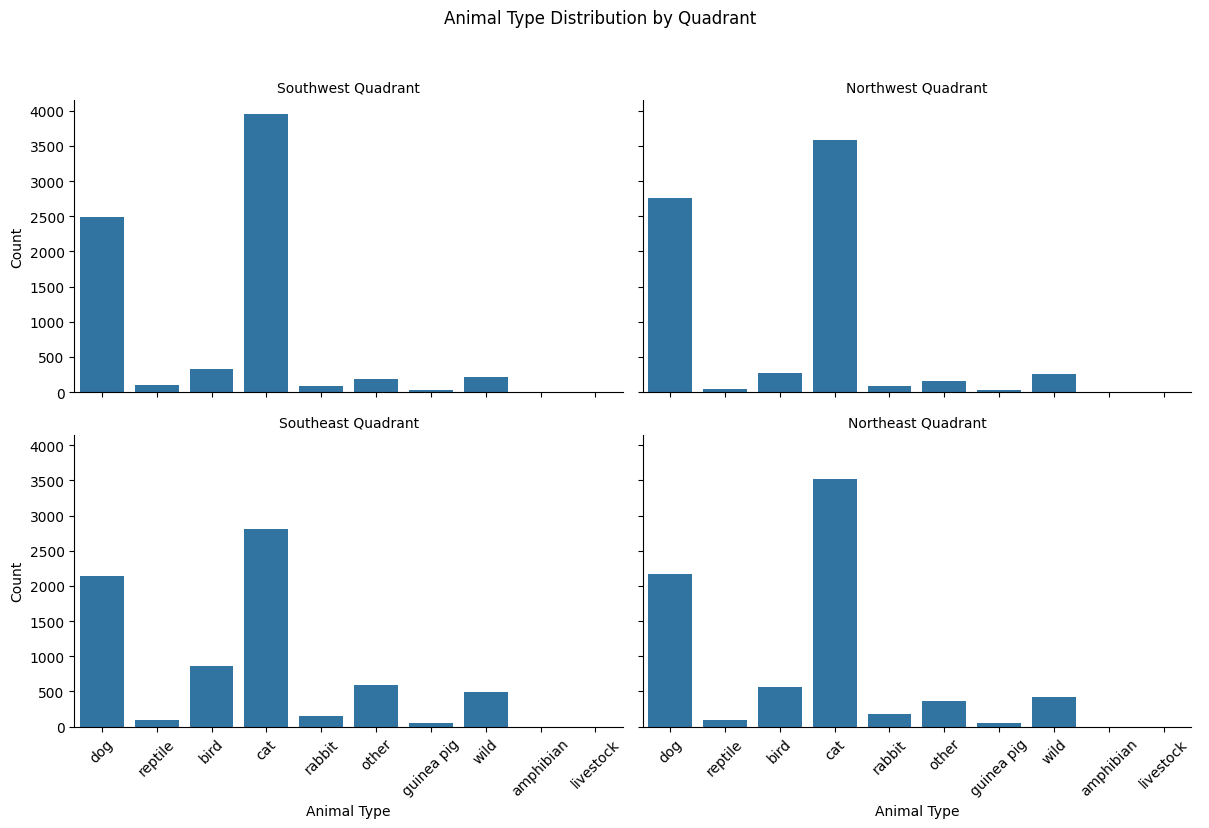

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume df_filtered is already defined from previous steps
# Assign quadrants based on median lat/lon
mid_lat = df_filtered['latitude'].median()
mid_lon = df_filtered['longitude'].median()

df_filtered['quadrant'] = 'unknown'
df_filtered.loc[
    (df_filtered['longitude'] < mid_lon) & (df_filtered['latitude'] < mid_lat),
    'quadrant'
] = 'Southwest'
df_filtered.loc[
    (df_filtered['longitude'] < mid_lon) & (df_filtered['latitude'] >= mid_lat),
    'quadrant'
] = 'Northwest'
df_filtered.loc[
    (df_filtered['longitude'] >= mid_lon) & (df_filtered['latitude'] < mid_lat),
    'quadrant'
] = 'Southeast'
df_filtered.loc[
    (df_filtered['longitude'] >= mid_lon) & (df_filtered['latitude'] >= mid_lat),
    'quadrant'
] = 'Northeast'

# Create faceted bar plot
g = sns.catplot(
    data=df_filtered,
    x='animal_type',
    kind='count',
    col='quadrant',
    col_wrap=2,
    height=4,
    aspect=1.5
)

g.set_titles("{col_name} Quadrant")
g.set_axis_labels("Animal Type", "Count")
g.fig.suptitle('Animal Type Distribution by Quadrant', y=1.03)
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

plt.tight_layout()
plt.show()


Question 2

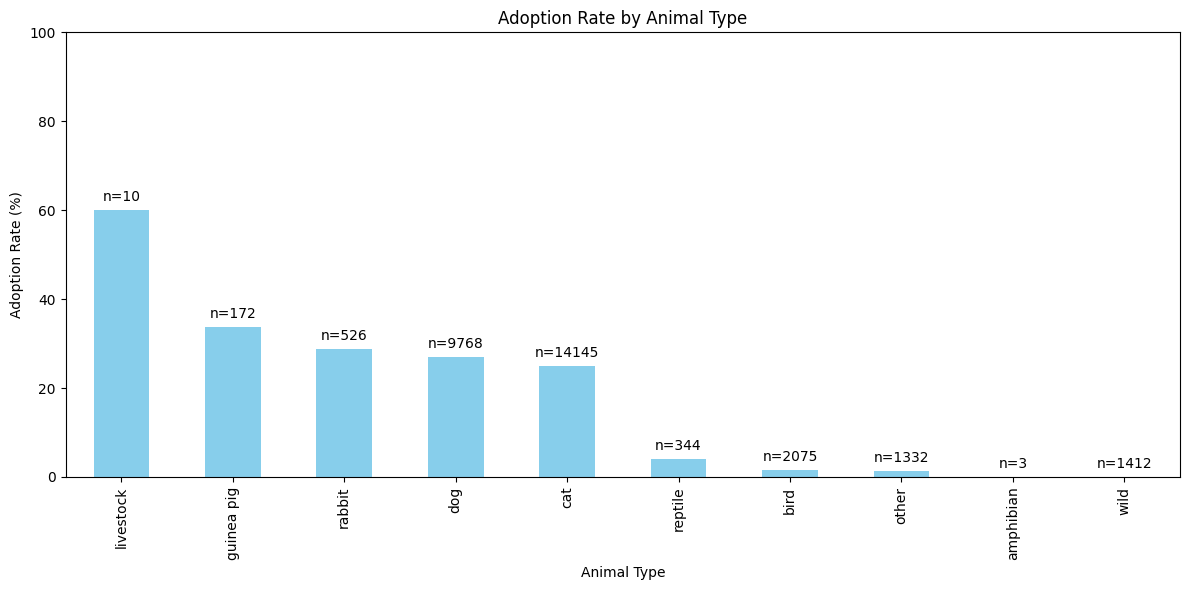

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('data/longbeach.csv')

# Create binary outcome variable: 1 for adopted, 0 for not adopted
df['is_adopted'] = df['outcome_type'].apply(lambda x: 1 if 'adopt' in str(x).lower() else 0)

# Calculate adoption rates by animal type
animal_adoption = df.groupby('animal_type')['is_adopted'].agg(['mean', 'count'])
animal_adoption['mean'] = animal_adoption['mean'] * 100  # Convert to percentage
animal_adoption = animal_adoption.sort_values('mean', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
ax = animal_adoption['mean'].plot(kind='bar', color='skyblue')
ax.set_xlabel('Animal Type')
ax.set_ylabel('Adoption Rate (%)')
ax.set_title('Adoption Rate by Animal Type')
ax.set_ylim(0, 100)

# Add count labels on top of bars
for i, v in enumerate(animal_adoption['mean']):
    count = animal_adoption['count'].iloc[i]
    ax.text(i, v + 2, f"n={count}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()



C:\Users\Tran Trung Duc\AppData\Local\Temp\ipykernel_17752\2681505158.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['intake_date'] = pd.to_datetime(df_cleaned['intake_date'], errors='coerce')
C:\Users\Tran Trung Duc\AppData\Local\Temp\ipykernel_17752\2681505158.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['outcome_date'] = pd.to_datetime(df_cleaned['outcome_date'], errors='coerce')
C:\Users\Tran Trung Duc\AppData\Local\Temp\ipykernel_17752\2681505158.py:12: SettingWithCo

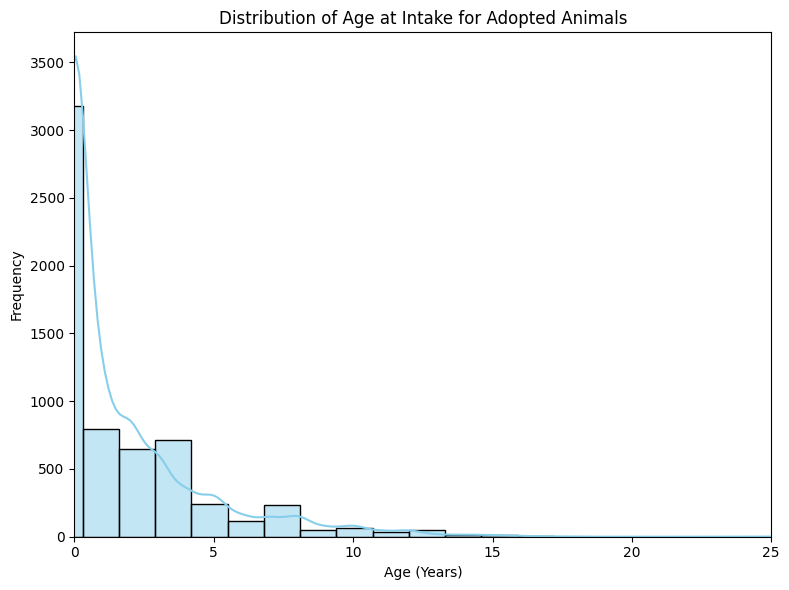

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

# Drop rows with missing critical fields
df_cleaned = df.dropna(subset=['outcome_type', 'animal_type', 'primary_color', 'sex', 'dob', 'intake_date', 'outcome_date'])

# Convert string columns to datetime
df_cleaned['intake_date'] = pd.to_datetime(df_cleaned['intake_date'], errors='coerce')
df_cleaned['outcome_date'] = pd.to_datetime(df_cleaned['outcome_date'], errors='coerce')
df_cleaned['dob'] = pd.to_datetime(df_cleaned['dob'], errors='coerce')

# Calculate age at intake (in years)
df_cleaned['age_at_intake'] = (df_cleaned['intake_date'] - df_cleaned['dob']).dt.days // 365

# Filter adopted animals only
adopted_data = df_cleaned[df_cleaned['outcome_type'].str.lower() == 'adoption']

# Plot histogram
plt.figure(figsize=(8, 6))
sns.histplot(adopted_data['age_at_intake'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Age at Intake for Adopted Animals')
plt.xlabel('Age (Years)')
plt.ylabel('Frequency')
plt.xlim(0, adopted_data['age_at_intake'].max())  # Start from 0
plt.tight_layout()
plt.show()


In [9]:
!pip install dash pandas plotly geopandas folium shapely

In [10]:
# Install required packages if needed
# !pip install pandas geopandas shapely folium dash plotly

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
import folium
from dash import Dash, html, dcc
import plotly.express as px

# Load & clean dataset
df = pd.read_csv('data/longbeach.csv')
df = df[['animal_type', 'latitude', 'longitude']].dropna()
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df = df.dropna(subset=['latitude', 'longitude'])

# Create filtered df for Long Beach area
df_filtered = df[
    (df['latitude'].between(33.7, 33.9)) &
    (df['longitude'].between(-118.25, -118.05))
]

# --------------------- FOLIUM MAP -----------------------
# Define income zones
zones = {
    'Downtown ($42,000)': [-118.22, 33.76, -118.18, 33.79],
    'West Side ($37,000)': [-118.23, 33.78, -118.19, 33.82],
    'East Side ($40,000)': [-118.14, 33.78, -118.09, 33.82],
    'North Long Beach ($35,000)': [-118.21, 33.87, -118.15, 33.90]
}

m = folium.Map(location=[33.8, -118.18], zoom_start=12)

# Add rectangles
for name, (min_lon, min_lat, max_lon, max_lat) in zones.items():
    folium.Rectangle(
        bounds=[(min_lat, min_lon), (max_lat, max_lon)],
        color='blue', fill=True, fill_opacity=0.2, popup=name
    ).add_to(m)

# Add animal points
for _, row in df_filtered.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color='red' if row['animal_type'].lower() == 'dog' else 'orange',
        fill=True,
        fill_opacity=0.4,
        popup=row['animal_type']
    ).add_to(m)

# Save map as HTML and embed
map_path = 'folium_map.html'
m.save(map_path)

# ----------------- QUADRANT BAR CHART ---------------------
mid_lat = df_filtered['latitude'].median()
mid_lon = df_filtered['longitude'].median()

def assign_quadrant(row):
    if row['longitude'] < mid_lon and row['latitude'] < mid_lat:
        return 'Southwest'
    elif row['longitude'] < mid_lon and row['latitude'] >= mid_lat:
        return 'Northwest'
    elif row['longitude'] >= mid_lon and row['latitude'] < mid_lat:
        return 'Southeast'
    else:
        return 'Northeast'

df_filtered['quadrant'] = df_filtered.apply(assign_quadrant, axis=1)

# Plotly bar chart
fig = px.histogram(
    df_filtered, x='animal_type', color='quadrant',
    barmode='group', facet_col='quadrant', facet_col_wrap=2,
    title='Animal Type Distribution by Quadrant'
)
fig.update_layout(height=600, showlegend=False)

# ----------------- DASH APP -------------------------
app = Dash(__name__)
app.title = "Long Beach Animal Dashboard"

app.layout = html.Div([
    html.H1("Long Beach Animal Dashboard", style={'textAlign': 'center'}),
    dcc.Tabs([
        dcc.Tab(label='Interactive Map', children=[
            html.Iframe(srcDoc=open(map_path, 'r').read(), width='100%', height='700')
        ]),
        dcc.Tab(label='Animal Type by Quadrant', children=[
            dcc.Graph(figure=fig)
        ])
    ])
])

# Export to static HTML file
from dash import DiskcacheManager
from dash._utils import AttributeDict
import dash

def export_dash(app, filename='dashboard.html'):
    from dash import Dash
    import plotly.io as pio
    from dash.testing.application_runners import import_app
    from selenium import webdriver
    import time

    # Instead of serving live, we use dash's snapshot saving via selenium
    from dash.development.base_component import Component
    from dash.development import base_component
    import dash.development.base_component as dbc

    import dash._utils as utils
    from dash._utils import AttributeDict

    app.run_server(debug=False, use_reloader=False)

# Save via Python's built-in HTTP server
app.run(debug=False, use_reloader=False)



C:\Users\Tran Trung Duc\AppData\Local\Temp\ipykernel_17752\2453238476.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['quadrant'] = df_filtered.apply(assign_quadrant, axis=1)


**Part 2: Interactive Dashboard**

In [11]:
!pip install pandas geopandas shapely dash plotly scipy seaborn

In [12]:
# Install necessary packages if needed
# !pip install pandas dash plotly scipy seaborn

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from dash import Dash, html, dcc, Input, Output
from scipy.stats import chi2_contingency
from datetime import datetime

# Load and preprocess data
df = pd.read_csv('data/longbeach.csv')
df = df[['animal_type', 'latitude', 'longitude', 'outcome_type', 'sex', 'intake_condition', 'primary_color', 'reason_for_intake', 'dob', 'intake_date', 'outcome_date']].dropna()
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df = df.dropna(subset=['latitude', 'longitude'])
df['is_adopted'] = df['outcome_type'].apply(lambda x: 1 if 'adopt' in str(x).lower() else 0)

# Assign quadrants based on median lat/lon
df_filtered = df[(df['latitude'].between(33.7, 33.9)) & (df['longitude'].between(-118.25, -118.05))].copy()
mid_lat = df_filtered['latitude'].median()
mid_lon = df_filtered['longitude'].median()

def assign_quadrant(row):
    if row['longitude'] < mid_lon and row['latitude'] < mid_lat:
        return 'Southwest'
    elif row['longitude'] < mid_lon and row['latitude'] >= mid_lat:
        return 'Northwest'
    elif row['longitude'] >= mid_lon and row['latitude'] < mid_lat:
        return 'Southeast'
    else:
        return 'Northeast'

df_filtered['quadrant'] = df_filtered.apply(assign_quadrant, axis=1)

# Quadrant plot
quadrant_fig = px.histogram(
    df_filtered, x='animal_type', color='quadrant', barmode='group',
    facet_col='quadrant', facet_col_wrap=2,
    title='Animal Type Distribution by Quadrant')
quadrant_fig.update_layout(height=600, showlegend=False)

# Chi-square analysis
adoption_vars = ['animal_type', 'sex', 'intake_condition', 'primary_color', 'reason_for_intake']
chi_data = pd.DataFrame({
    'Variable': adoption_vars,
    'Chi2': [chi2_contingency(pd.crosstab(df[var], df['is_adopted']))[0] for var in adoption_vars]
}).sort_values('Chi2', ascending=False)
chi_fig = px.bar(chi_data, x='Chi2', y='Variable', orientation='h', title='Chi-Square Statistic by Predictor Variable')

# Adoption rate bar chart function
def get_adoption_rate_fig(variable):
    grouped = df.groupby(variable)['is_adopted'].agg(['mean', 'count'])
    grouped['mean'] *= 100
    grouped = grouped.sort_values('mean', ascending=False).reset_index()
    fig = px.bar(grouped, x=variable, y='mean', text='count',
                 labels={'mean': 'Adoption Rate (%)'},
                 title=f'Adoption Rate by {variable.replace("_", " ").title()}')
    fig.update_traces(texttemplate='n=%{text}', textposition='outside')
    fig.update_layout(yaxis_range=[0, 100])
    return fig

# Age distribution plot
df['intake_date'] = pd.to_datetime(df['intake_date'], errors='coerce')
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
df['age_at_intake'] = (df['intake_date'] - df['dob']).dt.days // 365
adopted_data = df[df['outcome_type'].str.lower() == 'adoption']
hist_data = adopted_data['age_at_intake'].dropna()
counts, bins = np.histogram(hist_data, bins=20)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

age_fig = go.Figure()
age_fig.add_trace(go.Bar(x=bin_centers, y=counts, name='Histogram', marker_color='skyblue', opacity=0.6))
age_fig.update_layout(title='Distribution of Age at Intake for Adopted Animals', xaxis_title='Age (Years)', yaxis_title='Frequency')

# Dash app
app = Dash(__name__)

app.layout = html.Div([
    html.H1("Long Beach Animal Dashboard", style={'textAlign': 'center'}),
    dcc.Tabs([
        dcc.Tab(label='Animal Type by Quadrant', children=[dcc.Graph(figure=quadrant_fig)]),
        dcc.Tab(label='Adoption Rate Analysis', children=[
            html.Label("Select Variable:"),
            dcc.Dropdown(
                id='adoption-dropdown',
                options=[{'label': var.replace('_', ' ').title(), 'value': var} for var in adoption_vars],
                value='animal_type'
            ),
            dcc.Graph(id='adoption-rate-chart')
        ]),
        dcc.Tab(label='Chi-Square Test', children=[dcc.Graph(figure=chi_fig)]),
        dcc.Tab(label='Age Distribution for Adopted Animals', children=[dcc.Graph(figure=age_fig)])
    ])
])

@app.callback(
    Output('adoption-rate-chart', 'figure'),
    Input('adoption-dropdown', 'value')
)
def update_adoption_chart(variable):
    return get_adoption_rate_fig(variable)

if __name__ == '__main__':
    app.run(debug=False)

